In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem, zscore
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d
import pickle
from skimage import io
import glob
from itertools import combinations
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.graph_objects as go
import matplotlib.colors as mcolors

In [2]:
fly_nums=[226,227,228,234,239,240,241,242,249,250]

In [3]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
behave_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/behave_all'
if not os.path.exists(behave_dir):
    os.mkdir(behave_dir)


In [4]:
%%time
fictrac_data={}
for num in fly_nums:
    fictrac_data[num]={}
    fly_num = f'fly_{num}'
    func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'
    vision_path = os.path.join(func_path,'func_0', 'visual')
    ### Load Photodiode ###
    t, ft_triggers, pd1, pd2 = brainsss.load_photodiode(vision_path)
    stimulus_start_times = brainsss.extract_stim_times_from_pd(pd1, t)
    if stimulus_start_times.shape[0]<150:
        stimulus_start_times = brainsss.extract_stim_times_from_pd(pd2, t)

    # *100 puts in units of 10ms, which will match fictrac
    st_10ms = [int(stimulus_start_times[i]*100) for i in range(len(stimulus_start_times))]

    # get 1ms version to match neural timestamps
    st_ms= [i*10 for i in st_10ms]
    starts_loom = st_10ms
    starts_loom_ms = [n*10 for n in starts_loom]
    fictrac_path = os.path.join(func_path, 'func_0', 'fictrac')
    fictrac_raw = brainsss.load_fictrac(fictrac_path)

    fps = 100
    resolution = 10 #desired resolution in ms
    expt_len = fictrac_raw.shape[0]/fps*1000
    behaviors = ['dRotLabY', 'dRotLabZ', 'dRotLabX']
    fictrac_data[num]['behave'] = brainsss.smooth_and_interp_fictrac(fictrac_raw, fps, resolution, expt_len, behaviors[0])
    fictrac_data[num]['ts'] = np.arange(0,expt_len,resolution)

loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
loading photodiode data... done
CPU times: user 1min 5s, sys: 5.3 s, total: 1min 11s
Wall time: 1min 37s


(180000,)

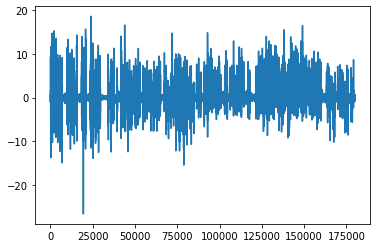

In [5]:
plt.plot(fictrac_data[250]['behave'])
fictrac_data[226]['behave'].shape

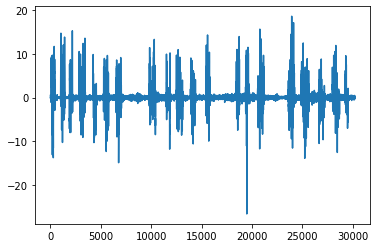

In [6]:
plt.plot(fictrac_data[250]['behave'][:starts_loom[0]])

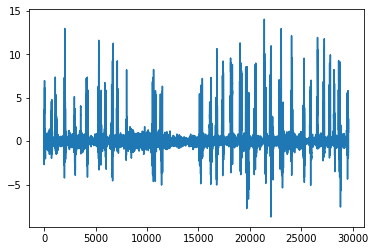

In [7]:
plt.plot(fictrac_data[250]['behave'][starts_loom[100]:starts_loom[140]])

In [8]:
# 100==1sec
val_pos=0.1 #10 #
val_neg=-0.1 #-10 #
great_pos=1 #100 #
great_neg=-1 #-100 #
behave_dict={}
for fly in fictrac_data:
    fly=str(fly)
    behave_dict[fly]={'inc':[],'dec':[],'flat':[]}
    first5=np.asarray(fictrac_data[int(fly)]['behave'][:starts_loom[0]])
    for i in range(len(first5)):
        if i+250<len(first5):
            pre=np.mean(first5[i:(i+50)])
            post=np.mean(first5[(i+100):(i+150)])
            if pre>val_neg and pre<val_pos and post>val_neg and post<val_pos:
#                 print(first5[i:(i+50)].max(),first5[i:(i+50)].min(),pre)
                if behave_dict[fly]['flat']==[] or behave_dict[fly]['flat'][-1]>i:
                    behave_dict[fly]['flat'].append(i)
                else:
                    if behave_dict[fly]['flat'][-1]+250<=i:
                        behave_dict[fly]['flat'].append(i)
            elif post>np.abs(pre*2):
    #         elif pre>great_neg and pre <val_pos and post>great_pos and post>np.abs(pre*2):
                if behave_dict[fly]['inc']==[] or behave_dict[fly]['inc'][-1]>i:
                    behave_dict[fly]['inc'].append(i)
                else:
                    if behave_dict[fly]['inc'][-1]+250<=i:
                        behave_dict[fly]['inc'].append(i)
            elif post<pre/2:
    #         elif pre>great_pos and post<val_pos and post>great_neg and post<pre/2:
                if behave_dict[fly]['dec']==[] or behave_dict[fly]['dec'][-1]>i:
                    behave_dict[fly]['dec'].append(i)
                else:
                    if behave_dict[fly]['dec'][-1]+250<=i:
                        behave_dict[fly]['dec'].append(i)
    behave_dict[fly]['inc']=np.array(behave_dict[fly]['inc'])
    behave_dict[fly]['dec']=np.array(behave_dict[fly]['dec'])
    behave_dict[fly]['flat']=np.array(behave_dict[fly]['flat'])

In [9]:
avg_be={'inc':[],'dec':[],'flat':[]}
for fly in behave_dict:
    for b in behave_dict[fly]:
#         print(b)
        arr=behave_dict[fly][b]
#         print(np.shape(arr))
        for tp in arr:
            avg_be[b].append(fictrac_data[int(fly)]['behave'][tp:(tp+250)])
avg_be['inc']=np.array(avg_be['inc'])
print(f'Inc: {avg_be["inc"].shape}')
avg_be['dec']=np.array(avg_be['dec'])
print(f'Dec: {avg_be["dec"].shape}')
avg_be['flat']=np.array(avg_be['flat'])
print(f'Flat: {avg_be["flat"].shape}')

Inc: (800, 250)
Dec: (933, 250)
Flat: (646, 250)


In [10]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#F5F5F5',
    'total': '#F5F5F5',
    'other': '#F5F5F5'
}

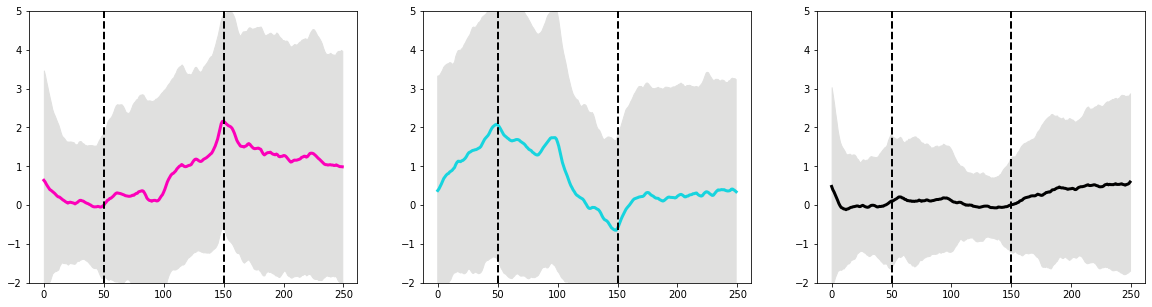

In [11]:
fig,axs=plt.subplots(1,len(list(avg_be.keys())),figsize=(20,5))
for i,be in enumerate(avg_be):
    mean_trace=np.mean(avg_be[be], axis=0)
    std_trace=np.std(avg_be[be], axis=0)
    axs[i].plot(mean_trace, color=behavior_colors[be],lw=3)
    axs[i].fill_between(np.arange(len(mean_trace)),mean_trace-std_trace, mean_trace+std_trace, color='#e0e0df')
    axs[i].axvline(50, linewidth=2, linestyle='--', color='k')
    axs[i].axvline(150, linewidth=2, linestyle='--', color='k')
    axs[i].set_ylim(-2, 5);


In [12]:
print(behave_dict.keys())
print(behave_dict['226'].keys())
print(behave_dict['226']['inc'])

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc', 'dec', 'flat'])
[  396   938  1308  1720  2138  2628  3108  3537  4022  4395  4660  4910
  5320  5626  5965  6217  6467  6717  6967  7278  7683  7986  8375  8784
  9086  9336  9633  9883 10351 10724 11203 11522 11938 12235 12569 12819
 13069 13341 13591 14072 14344 14594 14943 15193 15477 15884 16281 16531
 16904 17419 17899 18276 18648 18958 19491 19751 20074 20401 20746 21022
 21384 21787 22037 22439 22752 23227 23517 23807 24162 24412 24719 24969
 25350 25600 25850 26118 26574 26862 27112 27536 27801 28187 28631 28881
 29413 29702]


In [13]:
# new_event_name='first_5'
# event_list=behave_dict

# later_path = os.path.join(later_dir, f'{new_event_name}_event_times_split_dic.pkl')

# with open(later_path, 'wb') as file:
#     pickle.dump(event_list, file)